### Install OpenAI gymnasium package

In [1]:
pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 12.1 MB/s eta 0:00:00


## Import the libraries

In [4]:
import os
import torch
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import gymnasium as gym
from datetime import datetime
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [9]:
class CartPoleConstants:
    LEARNING_RATE = "LEARNING_RATE"
    GAMMA = "GAMMA"
    BATCH_SIZE = "BATCH_SIZE"
    ENTROPY_BETA_START = "ENTROPY_BETA_START"
    ENTROPY_BETA_END = "ENTROPY_BETA_END"
    ENTROPY_DECAY = "ENTROPY_DECAY"
    LR_DECAY_RATE = "LR_DECAY_RATE"
    LR_DECAY_INTERVAL = "LR_DECAY_INTERVAL"
    MAX_EPISODES = "MAX_EPISODES"


CARTPOLE_CONSTANTS = CartPoleConstants()

## Define the Policy network

In [5]:
class ReinforcementLearningPolicyNetwork(nn.Module):
    """A neural network model for the policy network in reinforcement learning policy gradient

    This network takes the environment's state as input and produces the probabilities for each action in the
     action space, used to select actions in a policy gradient algorithm
    """

    def __init__(self, input_dimension, output_dimension):
        """
        Initializes the policy network.

        Args:
            input_dimension (int): The dimension of the input (state space)
            output_dimension (int): The dimension of the output (action space)
        """
        super(ReinforcementLearningPolicyNetwork, self).__init__()

        # Fully connected layer that maps input dimension to 128 units
        self.layer1 = nn.Linear(input_dimension, 128)

        # Fully connected layer that maps 128 units to the output dimension
        self.layer2 = nn.Linear(128, output_dimension)

        # Apply softmax function to layer 2 to calculate action probabilities
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, input_state):
        """Forward pass through the policy network

        Args:
            input_state (torch.Tensor): Input state tensor

        Returns: The action probabilities after applying softmax to the network's output
        """
        # Apply ReLU activation after layer 1
        input_state = torch.relu(self.layer1(input_state))
        # Pass transformed_state through layer 2 and softmax
        input_state = self.softmax(self.layer2(input_state))
        return input_state

### Calculate discounted rewards

In [6]:
def calculate_discounted_rewards(rewards: list, gamma: float):
    """
    Args:
        rewards: A list or array of rewards received at each time step
        gamma: The discount factor used to discount future rewards usually between 0 and 1

    Returns: Discounted rewards, where each reward equals immediate reward + discounted future rewards
    """
    discounted_reward_values = np.zeros_like(rewards, dtype=np.float32)
    cumulative_reward = 0

    for _ in reversed(range(len(rewards))):
        cumulative_reward = rewards[_] + gamma * cumulative_reward
        discounted_reward_values[_] = cumulative_reward
    return discounted_reward_values

## Train the cartpole agent

In [7]:
# Window size for moving average of rewards
MOVING_AVERAGE_WINDOW = 50
# Starting exploration rate (full exploration)
MAX_EPISODES = 2000

def train_agent_with_policy_gradient(
    env,
    policy_net,
    optimizer,
    gamma,
    batch_size,
    learning_rate,
    entropy_decay,
    entropy_beta_start,
    entropy_beta_end,
    lr_decay_rate,
    lr_decay_interval,
    episodes=MAX_EPISODES,
    ):
    """The agent is trained using the reinforcement learning policy gradient method

    Args:
        env(gym.Env): OpenAI Gym environment to train the agent
        policy_net(torch.nn.Module): The policy network (neural network) that receives the state as input
         and produces action probabilities as output
        optimizer(torch.optim.Optimizer): Used to update the parameters of the policy network using the optimizer
        episodes(int): Total number of episodes for training the agent. The default value is MAX_EPISODES

    Returns:
        tuple: A tuple containing:
            - episode_rewards (list): The total reward per episode
            - smoothed_rewards (list): The moving average of rewards over a window
            - episode_lengths (list): The length (number of steps) of each episode
            - losses (list): The total loss per training batch
            - action_distribution (np.ndarray): The distribution of actions taken by the agent
            - entropies (list): The entropy loss for each episode, representing exploration
            - learning_rates (list): The learning rate at each episode
            - all_states (list): All states encountered during training
    """

    # Initialize lists to store results for each episode
    episode_rewards = []
    smoothed_rewards = []
    episode_lengths = []

    all_states_in_batch, actions_in_batch, rewards_in_batch = [], [], []

    # Store the loss values for monitoring training progress
    losses = []
    entropies = []
    action_distribution = np.zeros(env.action_space.n)
    learning_rates = []
    all_states = []
    epsilon = 1.0

    # Iterate through all the episodes for training
    for episode in range(episodes):
        # Initialise environment and fetch the initial state
        state, _ = env.reset()
        states, actions, rewards = [], [], []

        # Boolean flag to indicate if episode is completed(terminated)
        is_complete = False

        # Run the episode until it terminates
        while not is_complete:
            # Validate that the state is in the expected format
            if state is None or len(state) != 4:
                raise ValueError(f"Invalid state: {state}")

            # Convert state to tensor for feeding into the policy network
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            # Get action probabilities from policy network
            action_probs = policy_net(state_tensor)

            # Epsilon-greedy action selection (random exploration vs. exploitation of the learned policy)
            if np.random.rand() < epsilon:
                # Explore (random action)
                action = np.random.choice(len(action_probs[0]))
            else:
                 # Exploit (best action based on policy)
                action = torch.argmax(action_probs).item()

            # Take the selected action and observe the next state and reward
            next_state, reward, is_complete, truncated, _ = env.step(action)
            is_complete = is_complete or truncated  # Episode ends if either done or truncated

            # Store state, action, reward for backpropagation
            states.append(state_tensor)
            actions.append(action)
            rewards.append(reward)

            # Track the frequency of each action
            action_distribution[action] += 1

            # Update state for the next iteration
            state = next_state

        # After episode ends, normalize the rewards using discounted returns
        all_states_in_batch.extend(states)
        actions_in_batch.extend(actions)

        # Calculate discounted rewards
        rewards_in_batch.extend(calculate_discounted_rewards(rewards, gamma))
        all_states.extend(states)

        # Update epsilon to gradually decrease exploration as training progresses
        epsilon = max(0.1, 1 - episode / 1000)  # Epsilon decreases over time, but doesn't go below 0.1

        # Perform policy update every BATCH_SIZE episodes
        if (episode + 1) % batch_size == 0:
            optimizer.zero_grad()  # Zero out the gradients from the previous step

            # Convert batch data into tensors for training

            # Combine all state tensors in the batch into a single tensor
            all_states_in_batch = torch.cat(all_states_in_batch)

            # Convert the list of actions to a tensor of long integers
            actions_in_batch = torch.tensor(actions_in_batch, dtype=torch.long)

            # Convert the list of rewards to a tensor of floats
            rewards_in_batch = torch.FloatTensor(rewards_in_batch)

            # Normalize the rewards for better stability in training
            rewards_in_batch = (rewards_in_batch - rewards_in_batch.mean()) / (rewards_in_batch.std() + 1e-9)

            # Add policy and entropy losses for the relevant batch
            policy_losses, entropy_losses = [], []
            for state, action, reward in zip(all_states_in_batch, actions_in_batch, rewards_in_batch):
                # Get action probabilities for the current state
                action_probs = policy_net(state).squeeze(0)
                # Get the probability of the selected action
                action_prob = action_probs[action]

                # Calculate the policy loss (negative log probability * reward)
                policy_losses.append(-torch.log(action_prob) * reward)

                # Calculate the entropy loss (improve exploration by preventing deterministic policies)
                entropy_losses.append(-torch.sum(action_probs * torch.log(action_probs)))

            # Compute the entropy loss using dynamic entropy regularization
            entropy_beta = max(entropy_beta_end, entropy_beta_start * (entropy_decay ** episode))
            entropy_loss = entropy_beta * sum(entropy_losses)
            entropies.append(entropy_loss.item())

            # Total loss = Policy loss - Entropy loss (maximize reward while encouraging exploration)
            loss = sum(policy_losses) - entropy_loss
            losses.append(loss.item())

            # Backpropagate the gradients and update the policy network
            loss.backward()
             # Gradient clipping to avoid exploding gradients
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
            optimizer.step()  # Perform the optimization step

            # Clear the batch data for the next batch
            all_states_in_batch, actions_in_batch, rewards_in_batch = [], [], []

        # Save the total reward and episode length for each episode
        episode_rewards.append(sum(rewards))
        episode_lengths.append(len(rewards))

        # Compute the moving average of rewards for smoother tracking
        if len(episode_rewards) >= MOVING_AVERAGE_WINDOW:
            smoothed_rewards.append(np.mean(episode_rewards[-MOVING_AVERAGE_WINDOW:]))
        else:
            smoothed_rewards.append(np.mean(episode_rewards))

        # Store the current learning rate
        learning_rates.append(optimizer.param_groups[0]['lr'])

        # Apply learning rate decay at intervals defined by LR_DECAY_INTERVAL
        if episode % lr_decay_interval == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] = learning_rate * (lr_decay_rate ** (episode // lr_decay_interval))

        # Log progress every 100 episodes to monitor training
        if (episode % 100) == 0:
            print(f"Episode: {episode}, Total Reward: {sum(rewards)}, Smoothed Reward: {smoothed_rewards[-1]}")

        env.close()

    # Return all the results
    return episode_rewards, smoothed_rewards, episode_lengths, losses, action_distribution, entropies, learning_rates, all_states

## Analyse different metrics parameters

In [10]:
class CartPolePlotter:
    """Class for generating and saving plots for cartpole training using policy gradient reinforcement learning"""

    def __init__(
        self,
        output_dir="plots",
        ):
        self.output_dir = output_dir
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

    def save_plot(
        self,
        figure: matplotlib.figure.Figure,
        filename: str,
        ):
        timestamp = datetime.now().strftime("%Y-%m-%d::%H-%M-%S")
        filepath = os.path.join(self.output_dir, f"{filename}_{timestamp}.png")
        figure.savefig(filepath)
        plt.show()
        plt.close(figure)

    def plot_rewards_and_episode_lengths(
        self,
        rewards:list,
        smooth_rewards: list,
        lengths: list,
        filename: str ="rewards_and_lengths.png",
        ):
        figure, axis = plt.subplots(1, 2, figsize=(12, 6))

        axis[0].plot(rewards, label="Total Rewards", alpha=0.5)

        axis[0].plot(smooth_rewards, label="Smoothing Rewards", color="black")
        axis[0].set_xlabel("Episode")
        axis[0].set_ylabel("Total Rewards")
        axis[0].set_title("Rewards Over Time")
        axis[0].legend()

        axis[1].plot(lengths, label="Episode Length", color="orange")
        axis[1].set_xlabel("Episode")
        axis[1].set_ylabel("Episode Length")
        axis[1].set_title("Episode Length Over Time")
        axis[1].legend()

        self.save_plot(figure, filename)

    def plot_action_distribution(
        self,
        action_distribution:list ,
        env:gym.Env,
        filename: str ="action_distribution.png",
        ):
        figure, axis = plt.subplots(figsize=(6, 4))
        axis.bar(range(env.action_space.n), action_distribution / np.sum(action_distribution), color=['blue', 'red'])
        axis.set_xlabel("Action")
        axis.set_ylabel("Proportion")
        axis.set_title("Action Distribution")

        self.save_plot(figure, filename)

    def plot_policy_heatmap(
        self,
        policy_net: torch.nn.Module,
        env: gym.Env,
        num_samples: int =50,
        filename: str ="policy_heatmap.png",
        ):
        cartpole_position_values = np.linspace(-2.4, 2.4, num_samples)
        cartpole_velocity_values = np.linspace(-2, 2, num_samples)
        heatmap_data = np.zeros((num_samples, num_samples, env.action_space.n))

        for i, pos in enumerate(cartpole_position_values):
            for j, vel in enumerate(cartpole_velocity_values):
                state = torch.FloatTensor([pos, vel, 0, 0]).unsqueeze(0)
                action_probability = policy_net(state).detach().numpy()[0]
                heatmap_data[i, j, :] = action_probability

        fig, axs = plt.subplots(1, 2, figsize=(14, 7))
        for action in range(env.action_space.n):
            sns.heatmap(heatmap_data[:, :, action], ax=axs[action], xticklabels=10, yticklabels=10, cmap="YlGnBu")
            axs[action].set_title(f"Action {action} Probability Heatmap")
            axs[action].set_xlabel("Cart Velocity")
            axs[action].set_ylabel("Cart Position")

        plt.tight_layout()
        self.save_plot(fig, filename)

    def plot_loss_and_entropy(
        self,
        losses: list,
        entropies: list,
        filename: str ="loss_and_entropy.png",
        ):
        figure, axis = plt.subplots(1, 2, figsize=(12, 6))
        axis[0].plot(losses, label="Policy Loss", color="red")
        axis[0].set_xlabel("Batch")
        axis[0].set_ylabel("Loss")
        axis[0].set_title("Policy Loss Over Time")
        axis[0].legend()

        axis[1].plot(entropies, label="Entropy", color="green")
        axis[1].set_xlabel("Batch")
        axis[1].set_ylabel("Entropy")
        axis[1].set_title("Entropy Over Time")
        axis[1].legend()

        plt.tight_layout()
        self.save_plot(figure, filename)

    def plot_discounted_rewards(
        self,
        rewards: list,
        gamma: float,
        filename: str ="discounted_rewards.png",
        ):
        discounted = self.calculate_discounted_rewards(rewards, gamma)
        figure, axis = plt.subplots(figsize=(8, 6))
        axis.plot(rewards, label="Rewards")
        axis.plot(discounted, label="Discounted Rewards", linestyle="--")
        axis.set_xlabel("Time Step")
        axis.set_ylabel("Reward")
        axis.set_title("Discounted Reward Trajectory")
        axis.legend()
        self.save_plot(figure, filename)

    def plot_state_space(
        self,
        states: list,
        filename: str ="state_space.png",
        ):
        states = np.vstack([state.numpy() for state in states])  # Convert to numpy array
        pca = PCA(n_components=2)
        states_reduced = pca.fit_transform(states)

        figure, axis = plt.subplots(figsize=(8, 6))
        axis.scatter(states_reduced[:, 0], states_reduced[:, 1], c="blue", alpha=0.5)
        axis.set_title("2D State Space Visualization")
        axis.set_xlabel("PCA Dimension 1")
        axis.set_ylabel("PCA Dimension 2")
        axis.grid()
        self.save_plot(figure, filename)

    def plot_learning_rate_decay(
        self,
        learning_rates: list,
        filename : str ="learning_rate_decay.png"):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(learning_rates, label="Learning Rate")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Learning Rate")
        ax.set_title("Learning Rate Decay Over Time")
        ax.legend()
        self.save_plot(fig, filename)

    def plot_exploration_vs_exploitation(
        self,
        action_distribution: np.array,
        filename: str = "exploration_vs_exploitation.png",
        ):
        total_actions = np.sum(action_distribution)
        proportions = action_distribution / total_actions

        figure, axis = plt.subplots(figsize=(8, 6))
        axis.bar(range(len(proportions)), proportions, color=['blue', 'red'])
        axis.set_xlabel("Action")
        axis.set_ylabel("Proportion of Selection")
        axis.set_title("Exploration vs Exploitation")
        self.save_plot(figure, filename)

    def plot_discounted_rewards_heatmap(
        self,
        episode_rewards: list,
        gamma: float,
        filename: str = "discounted_rewards__heatmap.png",
        ):
        total_discounted_rewards = self.calculate_discounted_rewards(episode_rewards, gamma)

        figure, axis = plt.subplots(figsize=(12, 6))
        sns.heatmap([total_discounted_rewards], cmap="coolwarm", annot=False, cbar=True)
        axis.set_xlabel("Time Steps")
        axis.set_ylabel("Discounted Rewards")
        axis.set_title("Discounted Rewards Heatmap")

        self.save_plot(figure, filename)

    def calculate_discounted_rewards(
        self,
        rewards: list,
        gamma: float,
        ):
        total_discounted_rewards = np.zeros_like(rewards, dtype=np.float32)
        cumulative_reward = 0

        for t in reversed(range(len(rewards))):
            cumulative_reward = rewards[t] + gamma * cumulative_reward
            total_discounted_rewards[t] = cumulative_reward
        return total_discounted_rewards

    def create_report(
        self,
        training_results: list,
        filename: str = "reports/training_result_report.csv",
        ):
        df = pd.DataFrame(training_results)
        df.to_csv(filename, index=False)
        print(f"Training report saved to {filename}")

    def plot_reward_training_loss_curve(self):
      plt.figure(figsize=(12, 6))

      # Reward vs Episode
      plt.subplot(2, 4, 1)
      plt.plot(episode_rewards)
      plt.xlabel('Episode')
      plt.ylabel('Total Reward')
      plt.title('Episode Rewards')

      # Episode Lengths
      plt.subplot(2, 4, 2)
      plt.plot(episode_lengths)
      plt.xlabel('Episode')
      plt.ylabel('Episode Length')
      plt.title('Episode Lengths')

      # Loss Curve
      plt.subplot(2, 4, 3)
      plt.plot(losses)
      plt.xlabel('Episode')
      plt.ylabel('Loss')
      plt.title('Loss Curve')


      # Training Error
      training_error = np.array(episode_rewards) - np.mean(episode_rewards)
      plt.subplot(2, 4, 4)
      plt.plot(training_error)
      plt.xlabel('Episode')
      plt.ylabel('Training Error')
      plt.title('Training Error')

      plt.tight_layout()
      plt.show()

def collect_summary(
    episode_rewards: list,
    smoothed_rewards: list,
    run_id: str,
    config: dict,
    episode_lengths: list,
    losses: list,
    entropies: list,
    interval: int =100,
    ):
    """Collect episode-wise summary for a single run."""
    summary = []
    for i in range(0, len(episode_rewards), interval):
        summary.append({
            "Run ID": run_id,
            "Episode": i,
            "Total Reward": episode_rewards[i],
            "Smoothed Reward": smoothed_rewards[i],
            "Episode Length": episode_lengths[i],
            "Loss": losses[i] if i < len(losses) else None,
            "Entropy": entropies[i] if i < len(entropies) else None,
            "Learning Rate": config[CARTPOLE_CONSTANTS.LEARNING_RATE],
            "Gamma": config[CARTPOLE_CONSTANTS.GAMMA],
            "Batch Size": config[CARTPOLE_CONSTANTS.BATCH_SIZE],
            "Max Episodes": config[CARTPOLE_CONSTANTS.MAX_EPISODES],
        })
    return summary

plotter = CartPolePlotter()

## Define the different metric parameters
* LEARNING_RATE:
  * The learning rate controls the magnitude of adjustments made to the model's parameters based on the estimated error during each weight update. A high learning rate may cause the model to overshoot the optimal values, while a low learning rate may result in slower training and the risk of getting stuck in local minima.
  * Usually between 1e-5 and 1e-3, based on the complexity of the environment and model.

* GAMMA:  
  * The discount factor determines the importance of future rewards in decision-making. A gamma value near 0 causes the agent to prioritize immediate rewards, whereas a value close to 1 encourages the agent to consider long-term rewards.
  * Usually between 0 and 1 (commonly between 0.9 and 0.99).
  * For each step, the reward is discounted by multiplying it by gamma:   
     discounted_reward = reward + gamma * future_reward

* BATCH_SIZE:
  * The batch size specifies the number of episodes or time steps the agent processes before updating the weights. A larger batch size can result in more stable updates but demands more memory and computational power. In contrast, a smaller batch size enables quicker updates but may introduce more noise.
  * Usually range between 8 and 64 (in reinforcement learning)

* ENTROPY_BETA_START
  * The initial value of the entropy regularization coefficient (beta) in the loss function. Entropy regularization encourages the agent to explore more by discouraging overly deterministic policies. A higher value promotes greater exploration
  * Usually range between 0.01 and 0.1, depending on how much exploration is needed

* ENTROPY_BETA_END
  * The final value of the entropy regularization coefficient (beta). During training, entropy is gradually reduced (annealed) from the starting value (ENTROPY_BETA_START) to the final value (ENTROPY_BETA_END), encouraging a shift from exploration to exploitation as the agent learns
 * Usually range between 0.001 and 0.01, usually smaller than

* ENTROPY_DECAY
  * The rate at which the entropy regularization coefficient decays from ENTROPY_BETA_START to ENTROPY_BETA_END. This determines how quickly the agent transitions from a focus on exploration (high entropy) to exploitation (low entropy)
  * Typical Range: Values close to 1 (e.g., 0.99) result in slow decay, while smaller values lead to faster decay

* LR_DECAY_RATE
  * The rate at which the learning rate decays over time. This helps fine-tune the learning process by preventing overshooting as the model converges. The learning rate is typically reduced using an exponential decay formula.
  learning_rate = learning_rate * decay_rate after each LR_DECAY_INTERVAL.
  * Usually range between 0.95 and 0.99.

* LR_DECAY_INTERVAL
  *  The number of episodes or steps between each adjustment of the learning rate. The learning rate is decayed by the LR_DECAY_RATE after each interval.
  * Varies but intervals of 100 to 1000 episodes or steps are common.

* MAX_EPISODES:
  * The maximum number of training episodes the agent will undergo. This sets the upper limit on the agent's interactions with the environment. While increasing the number of episodes gives the agent more time to learn, it also increases computational costs.
  * Usually range between 1000 and 5000 episodes, depending on the complexity of the task and available resources.

In [11]:
LEARNING_RATE = 0.01
GAMMA = 0.99
BATCH_SIZE = 20
ENTROPY_BETA_START = 0.01
ENTROPY_BETA_END = 0.001
ENTROPY_DECAY = 0.999
LR_DECAY_RATE = 0.98
LR_DECAY_INTERVAL = 100
MAX_EPISODES = 2000

In [12]:
env = gym.make("CartPole-v1")

input_dimension = env.observation_space.shape[0]
print(f"input dimension {input_dimension}")
output_dimension = env.action_space.n
print(f"output dimension {output_dimension}")

policy_net = ReinforcementLearningPolicyNetwork(input_dimension, output_dimension)
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)

input dimension 4
output dimension 2


In [13]:
episode_rewards, smoothed_rewards, episode_lengths, losses, action_distribution, entropies, learning_rates, all_states = train_agent_with_policy_gradient(
    env,
    policy_net,
    optimizer,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    entropy_decay=ENTROPY_DECAY,
    entropy_beta_start=ENTROPY_BETA_START,
    entropy_beta_end=ENTROPY_BETA_END,
    lr_decay_rate=LR_DECAY_RATE,
    lr_decay_interval=LR_DECAY_INTERVAL,
    episodes=MAX_EPISODES,
    )

Episode: 0, Total Reward: 12.0, Smoothed Reward: 12.0
Episode: 100, Total Reward: 27.0, Smoothed Reward: 28.2
Episode: 200, Total Reward: 54.0, Smoothed Reward: 32.66
Episode: 300, Total Reward: 25.0, Smoothed Reward: 34.82
Episode: 400, Total Reward: 21.0, Smoothed Reward: 46.8
Episode: 500, Total Reward: 107.0, Smoothed Reward: 52.92
Episode: 600, Total Reward: 53.0, Smoothed Reward: 73.0
Episode: 700, Total Reward: 85.0, Smoothed Reward: 110.44
Episode: 800, Total Reward: 84.0, Smoothed Reward: 132.78
Episode: 900, Total Reward: 174.0, Smoothed Reward: 237.28
Episode: 1000, Total Reward: 280.0, Smoothed Reward: 265.56
Episode: 1100, Total Reward: 500.0, Smoothed Reward: 444.72
Episode: 1200, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1300, Total Reward: 500.0, Smoothed Reward: 499.2
Episode: 1400, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1500, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1600, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1700, T

##  Evaluating Policy Performance on CartPole-v1 environment

The test_policy function evaluates a reinforcement learning agent's policy on the CartPole-v1 environment. The agent selects actions based on its current policy network, and the environment is rendered during the test. After each episode, the total reward achieved by the agent is displayed, offering a measure of the agent's performance. The testing process runs for a set number of episodes (default of 5) to assess the policy's ability to balance the pole.

In [14]:
def test_policy(env, policy_net, episodes=5):
    for episode in range(episodes):
        reset_result = env.reset()
        if isinstance(reset_result, tuple):
            state, _ = reset_result
        else:
            state = reset_result

        done = False
        total_reward = 0
        while not done:
            env.render()
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action_probs = policy_net(state_tensor).detach().numpy()[0]
            action = np.argmax(action_probs)

            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, _ = step_result
                terminated, truncated = done, False
            else:
                next_state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

            total_reward += reward
            state = next_state

        print(f"Test Episode {episode + 1}: Total Reward: {total_reward}")
    env.close()

# Initialize environment with render_mode='human'
env = gym.make('CartPole-v1', render_mode='human')
test_policy(env, policy_net)

Test Episode 1: Total Reward: 500.0
Test Episode 2: Total Reward: 500.0
Test Episode 3: Total Reward: 500.0
Test Episode 4: Total Reward: 500.0
Test Episode 5: Total Reward: 500.0


As we can see from the training results above that the agent has successfully learned an optimal policy, consistently achieving the maximum reward of 500 in each test episode, demonstrating stable and effective training.

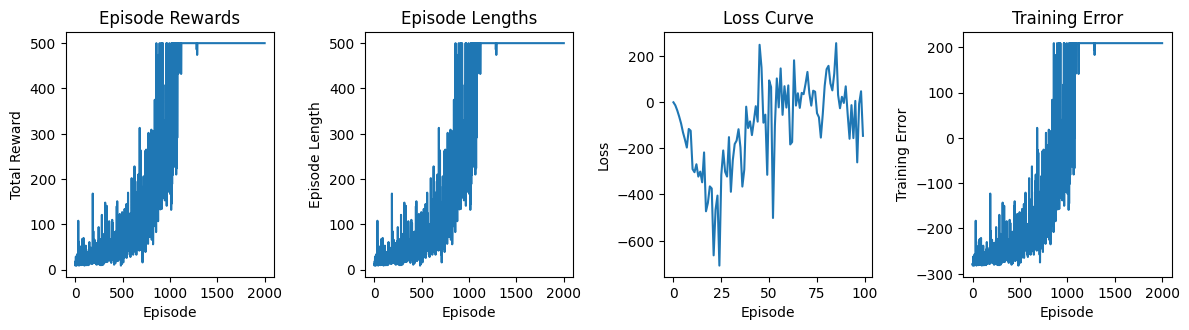

In [19]:
plotter.plot_reward_training_loss_curve()

- **Rewards and Episode Lengths**: The agent's performance steadily improves, consistently achieving the maximum reward of 500 by around episode 1100, indicating successful learning of the optimal policy.

- **Loss Curve**: The initial fluctuations in loss reflect active exploration and learning, which stabilize as the training progresses, indicating convergence.

- **Training Error**: The decreasing trend in training error highlights the agent's improving and stabilizing policy as it learns to maximize rewards.

In summary, the agent shows significant progress and policy stability after adequate training.

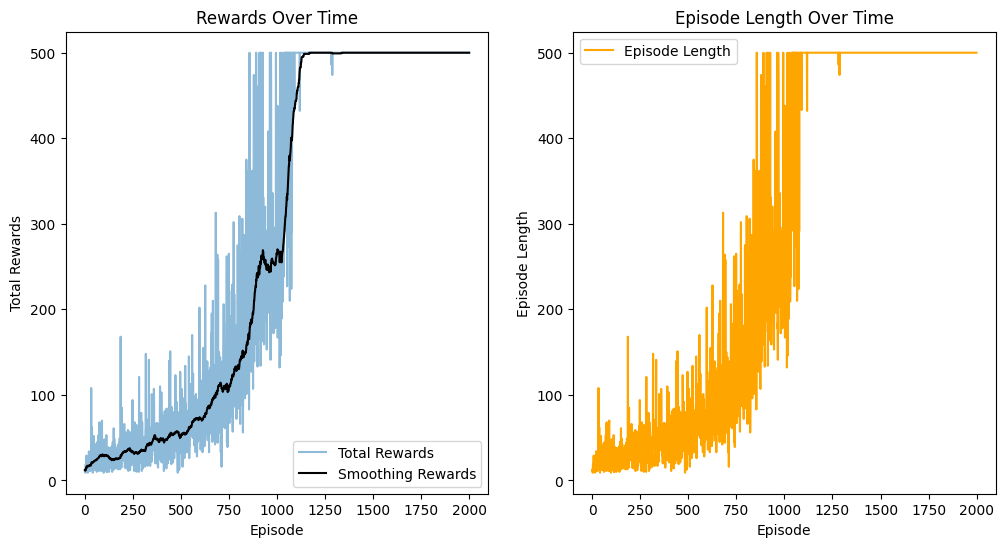

In [20]:
plotter.plot_rewards_and_episode_lengths(episode_rewards, smoothed_rewards, episode_lengths)

Overall, these plots demonstrate that the agent successfully learns the task over time, with increasing rewards and episode lengths as training progresses. The smoothing in rewards and the upward trend in episode lengths indicate significant learning and consistent performance improvements.

1. The rewards over time shows how the total rewards evolve across episodes during the training of the agent.
2. Initially, the rewards are low, but they increase steadily as the agent learns to perform better in the environment. By around episode 1000, the rewards consistently approach the maximum (500), indicating that the agent has learned to keep the pole upright for nearly the entire episode duration.
3. The episode length over time plot tracks how the length of each episode (number of time steps before termination) changes as training progresses
4. Initially, episodes are short, reflecting the agent's inability to balance the pole effectively. As training progresses, the episode lengths increase, showing improved performance. Eventually, most episodes reach the environment's limit (500 steps), indicating that the agent has completed learning for the task.
5. Toward the end of training, some variability in episode length is observed. This may be due to exploration or slight inconsistencies in performance.

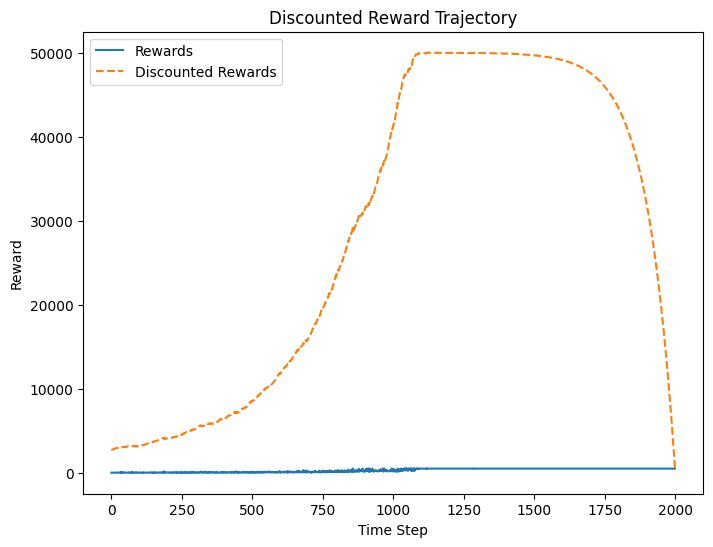

In [21]:
plotter.plot_discounted_rewards(episode_rewards, gamma=GAMMA)

The **Discounted Reward Trajectory** plot highlights that while the total rewards remain stable, the discounted rewards increase significantly, peak midway, and then decrease. This reflects the agent’s shift from focusing on short-term gains to prioritizing long-term rewards as training progresses.

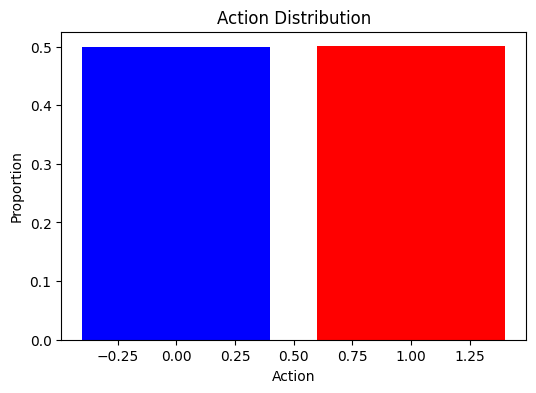

In [22]:
plotter.plot_action_distribution(action_distribution, env)

1. The above plot shows the distribution of actions selected by the agent for the entire during of training.  

2. The x-axis indicates the action index (0 or 1 for CartPole), while the y-axis shows the proportion of times each action was chosen. Initially, the agent appears to select both actions with approximately equal frequency, which is typical during the exploration phase. Over time, as the agent learns, it is expected to favor actions that yield higher rewards.

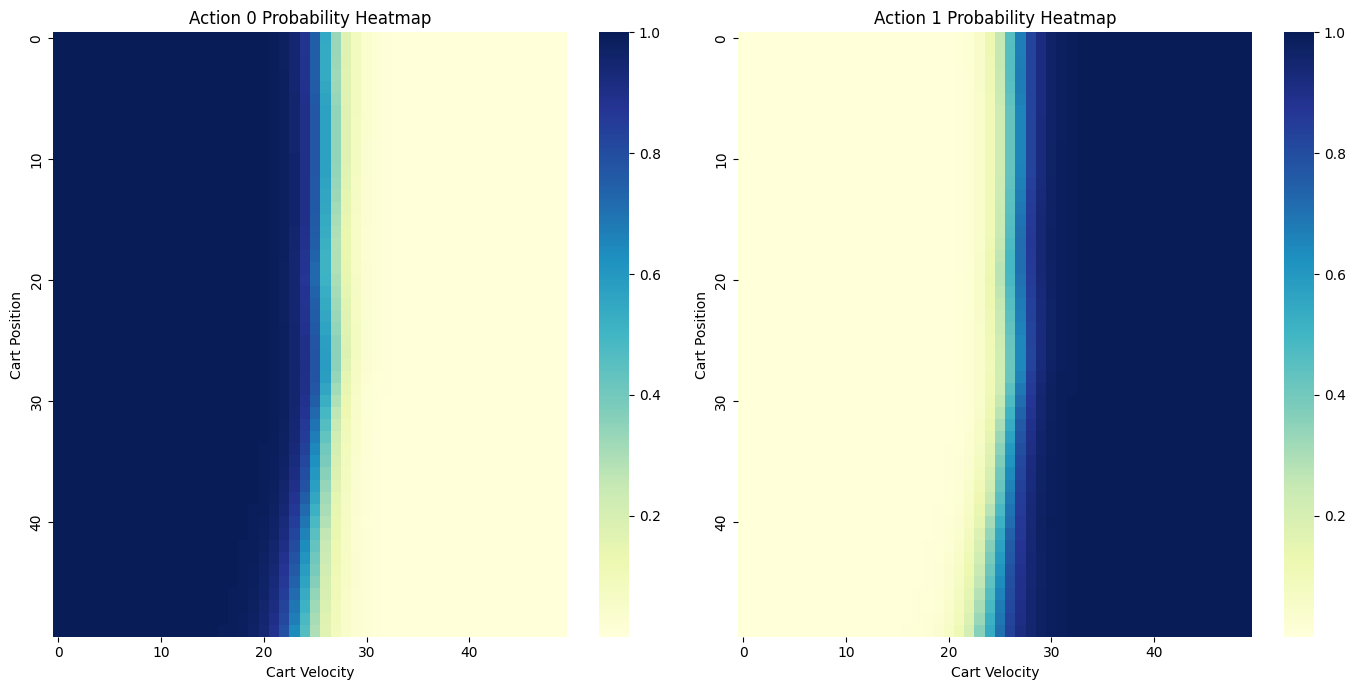

In [23]:
plotter.plot_policy_heatmap(policy_net, env)

1. These heatmaps visualize the probability of taking each action for different combinations of cart position and velocity.
2. x-axis represents the cart velocity
3. y-axis represents the cart position.
4. The color intensity represents the probability of taking the action.
5. Action 0 Probability Heatmap: The plot shows that the agent is more likely to take Action 0 (likely moving the cart to the right) when the cart is in the leftmost region of the state space (negative cart position). This makes sense because the agent needs to move the cart to the right to balance the pole.
As the cart moves towards the center, the probability of Action 0 decreases.
When the cart is in the rightmost region of the state space, the probability of Action 0 increases again.
6. Action 1 Probability Heatmap: The plot shows the opposite behavior compared to Action 0. The agent is more likely to take Action 1 (likely moving the cart to the left) when the cart is in the rightmost region of the state space.



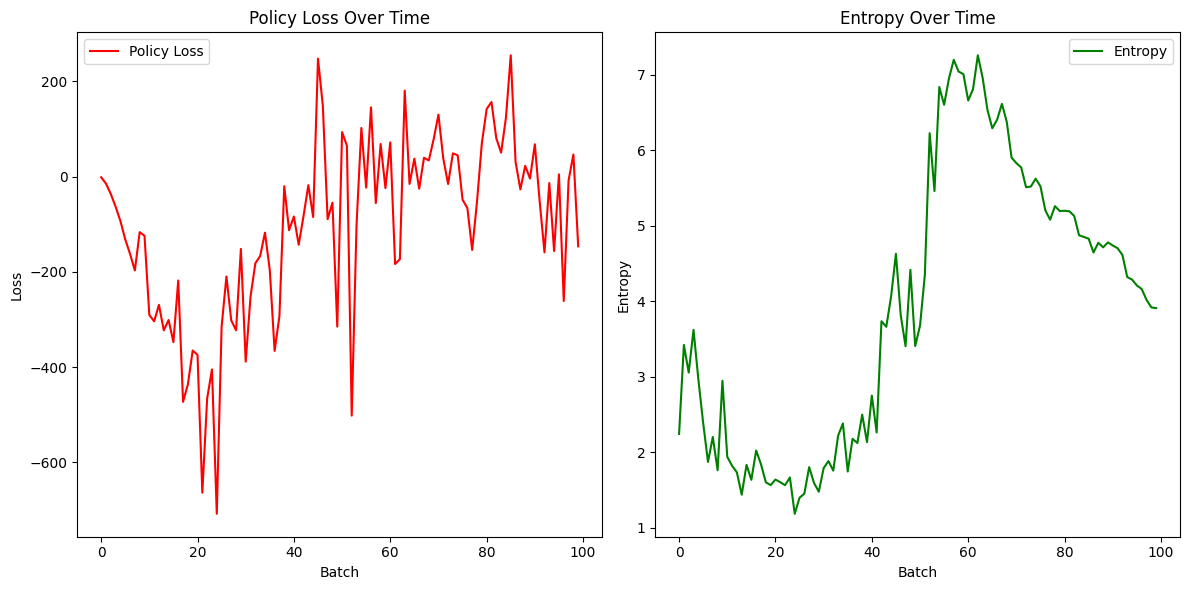

In [24]:
plotter.plot_loss_and_entropy(losses=losses, entropies=entropies)

##### **Policy Loss Oevr Time**

1. The policy loss shows a consistent downward trend, indicating that the agent is learning and improving. This decline suggests the agent is minimizing the error between its chosen actions and the optimal ones.
2. Although the overall trend is downward, the loss curve displays noticeable fluctuations. These can be attributed to several factors:
  - Exploration vs. Exploitation: The agent may be experimenting with different strategies, which can temporarily increase the loss.
 - Batch Size and Gradient Updates: Smaller batch sizes or infrequent updates can introduce variability and noise into the loss curve.
 - While CartPole is relatively straightforward, the agent's efforts to fine-tune its policy can still cause some instability in the loss values.

 #### **Entropy Over Time**
 1. The decreasing policy loss indicates that the agent is progressively improving and improving its decision-making process.
 2. A decline in entropy reflects that the agent’s actions are becoming more confident and intentional, resulting in a more stable and efficient policy over time.
 3. The variability in both plots is a common characteristic of reinforcement learning and can be attributed to:
 - The inherent randomness of the environment.
 - The ongoing balance between exploration and exploitation.
 - Gradient updates causing shifts in the learning process.

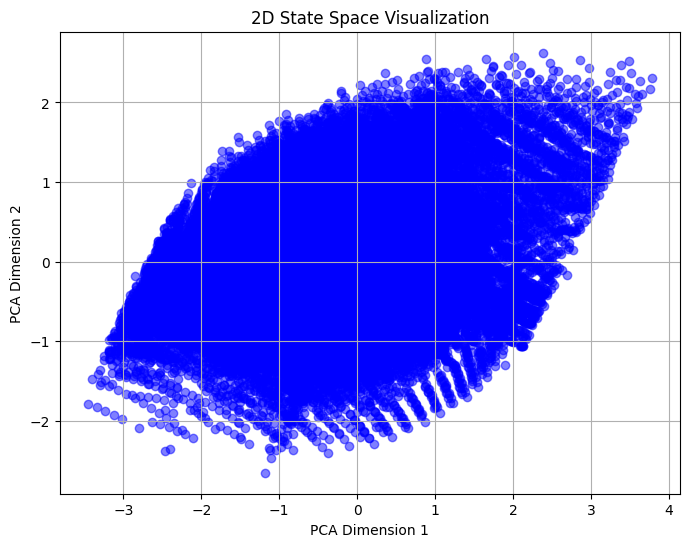

In [25]:
plotter.plot_state_space(all_states)

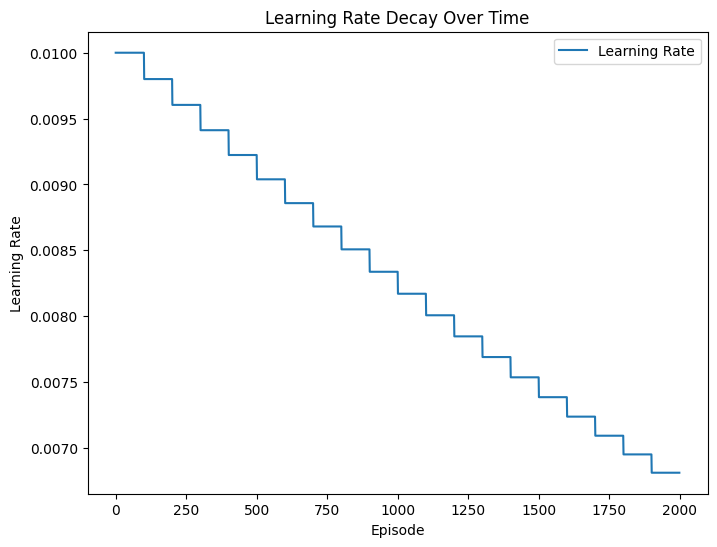

In [17]:
plotter.plot_learning_rate_decay(learning_rates=learning_rates)

This plot depicts the progression of the learning rate throughout training. The x-axis represents episode numbers, while the y-axis indicates the learning rate at each step.

1. The learning rate decreases in fixed intervals, remaining steady for several episodes before dropping to a lower value. This helps maintain training stability while progressively encouraging finer adjustments.
2. Training starts with a relatively high learning rate, enabling broad exploration and quick acquisition of diverse experiences.
3. As training progresses, the learning rate decreases, facilitating more precise policy updates and reducing the risk of destabilizing the learning process.
4. The following insights can be drawn:
  - A high initial learning rate encourages exploration, allowing the agent to experiment with various actions and discover promising strategies. This helps prevent premature convergence to suboptimal policies.
  - As the learning rate decreases, the agent focuses more on refining its current policy.
  - The step-wise decay strategy balances exploration and exploitation, helping the agent converge to an optimal or near-optimal solution over time.

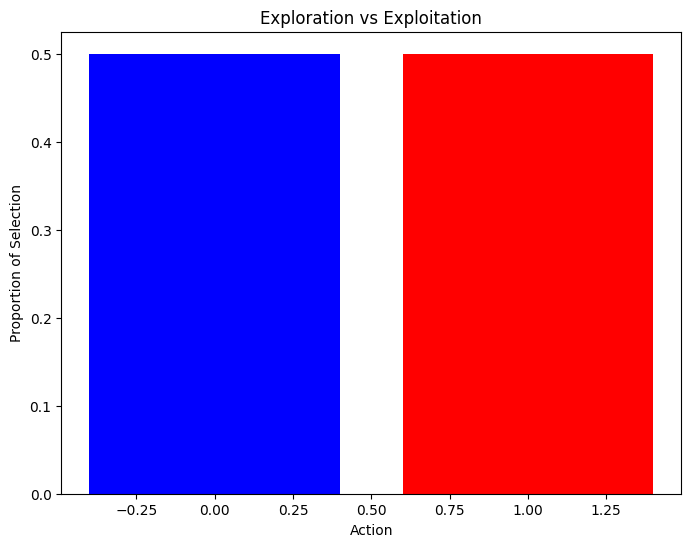

In [28]:
plotter.plot_exploration_vs_exploitation(action_distribution)

This bar chart displays the distribution of actions taken by the agent throughout the training process. The x-axis shows the action index (0 or 1 in the CartPole environment), while the y-axis represents the proportion of times each action was selected.

-  The height of the bars for both actions is approximately equal, indicating that the agent is selecting both actions with similar frequency. This suggests the agent is in an exploratory phase, experimenting with different actions to find the optimal policy.
  - This chart may reflect an early stage of training, where the agent is still exploring and has not yet converged to a more refined policy.
  - The agent is likely balancing exploration (trying both actions) and exploitation (relying on the best-known action). Maintaining this balance is key to effective learning.

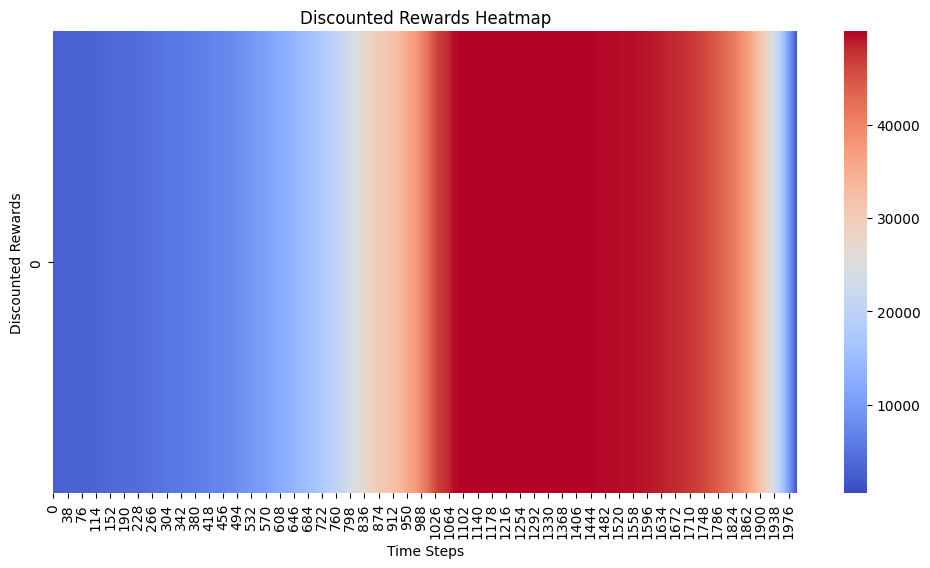

In [29]:
plotter.plot_discounted_rewards_heatmap(episode_rewards, gamma=GAMMA)

1. The heatmap displays discounted rewards across time steps, with the x-axis representing time and the y-axis indicating the corresponding reward values. Darker colors signify higher reward magnitudes, while lighter shades indicate lower values.
2. The rise in discounted rewards indicates that the agent is improving its decision-making and earning higher rewards as training progresses.The variations in reward values suggest the agent's exploration of different strategies, driven by the inherent randomness of reinforcement learning.
3. Darker regions represent higher discounted rewards, while lighter areas correspond to lower rewards.
4. The following insights can be drawn:
- The increase in rewards reflects that the agent is effectively learning and mastering the task.
- The fluctuations highlight the agent's balancing act between exploring new actions and exploiting known strategies
- The discounted rewards emphasize the long-term value of actions, steering the agent toward optimal policies.

## Train the agent for defined parameters

In [30]:
LEARNING_RATE = 0.015
GAMMA = 0.9
ENTROPY_BETA_START = 0.3
ENTROPY_BETA_END = 0.01
ENTROPY_DECAY = 0.999
LR_DECAY_RATE = 0.95
LR_DECAY_INTERVAL = 200


env = gym.make("CartPole-v1")
policy_net = ReinforcementLearningPolicyNetwork(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
episode_rewards2, smoothed_rewards2, episode_lengths2, losses2, action_distribution2, entropies2, learning_rates2, all_states2 = train_agent_with_policy_gradient(
    env,
    policy_net,
    optimizer,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    entropy_decay=ENTROPY_DECAY,
    entropy_beta_start=ENTROPY_BETA_START,
    entropy_beta_end=ENTROPY_BETA_END,
    lr_decay_rate=LR_DECAY_RATE,
    lr_decay_interval=LR_DECAY_INTERVAL,
    episodes=MAX_EPISODES,
    )

Episode: 0, Total Reward: 16.0, Smoothed Reward: 16.0
Episode: 100, Total Reward: 15.0, Smoothed Reward: 27.48
Episode: 200, Total Reward: 66.0, Smoothed Reward: 28.44
Episode: 300, Total Reward: 22.0, Smoothed Reward: 40.32
Episode: 400, Total Reward: 39.0, Smoothed Reward: 43.6
Episode: 500, Total Reward: 51.0, Smoothed Reward: 63.28
Episode: 600, Total Reward: 47.0, Smoothed Reward: 74.2
Episode: 700, Total Reward: 80.0, Smoothed Reward: 112.2
Episode: 800, Total Reward: 166.0, Smoothed Reward: 171.06
Episode: 900, Total Reward: 500.0, Smoothed Reward: 417.82
Episode: 1000, Total Reward: 484.0, Smoothed Reward: 483.94
Episode: 1100, Total Reward: 449.0, Smoothed Reward: 487.5
Episode: 1200, Total Reward: 500.0, Smoothed Reward: 459.28
Episode: 1300, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1400, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1500, Total Reward: 500.0, Smoothed Reward: 497.38
Episode: 1600, Total Reward: 500.0, Smoothed Reward: 500.0
Episode: 1700, 

## Plot and analyse training for the given parameters

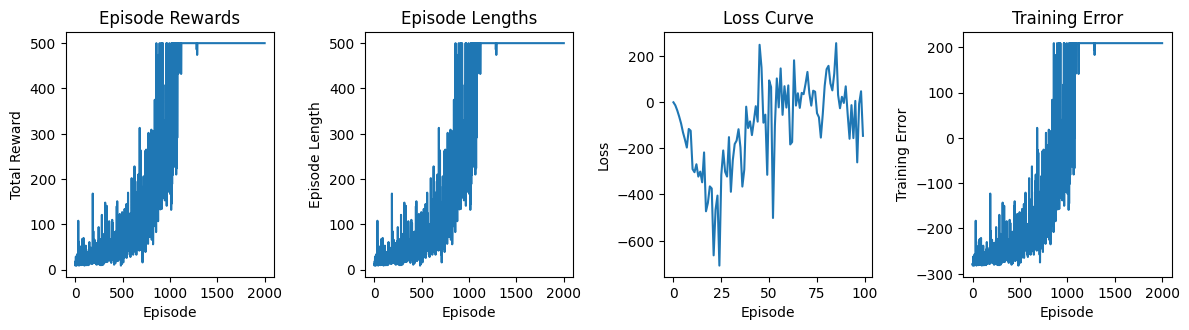

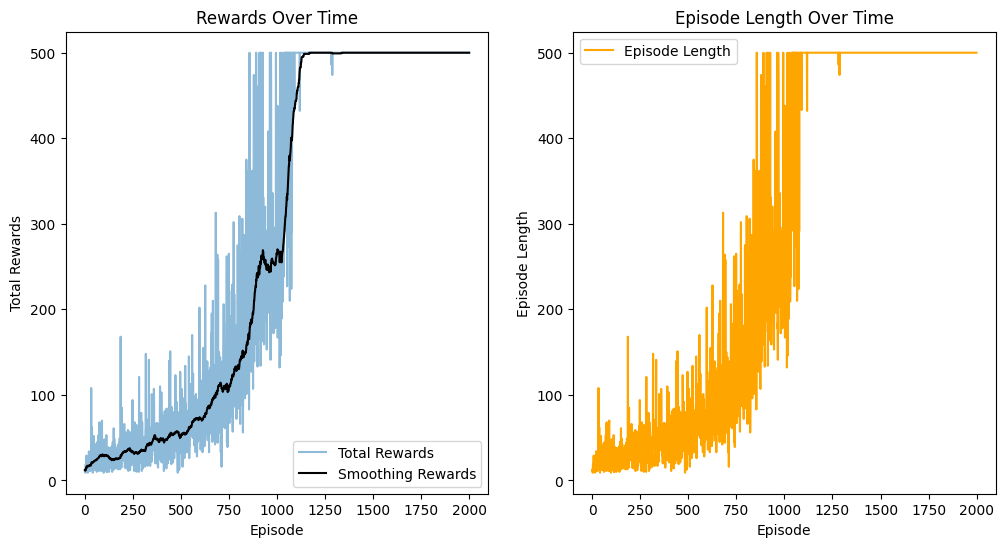

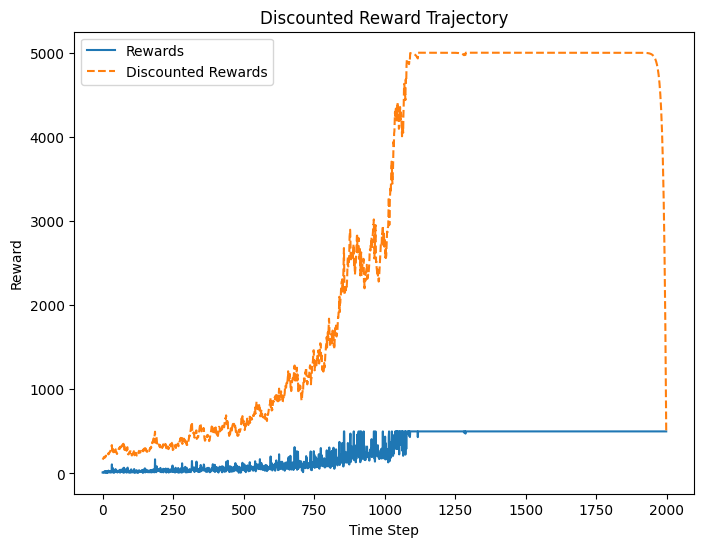

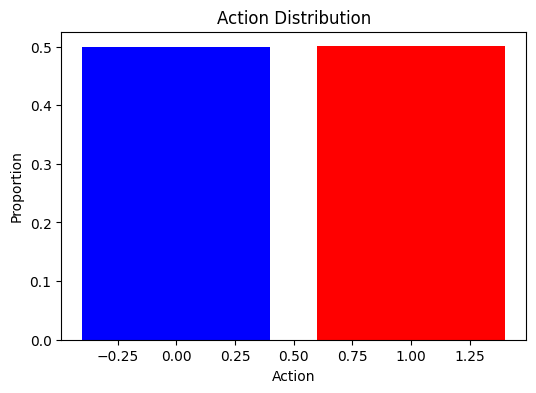

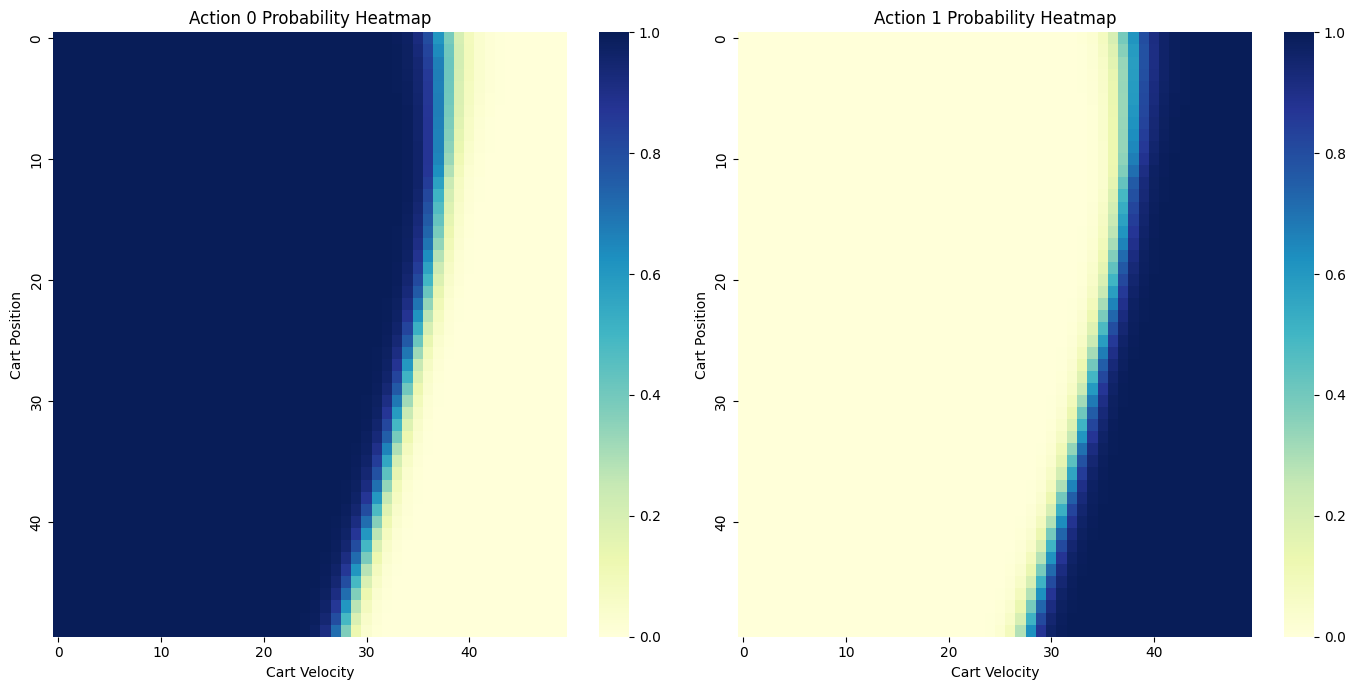

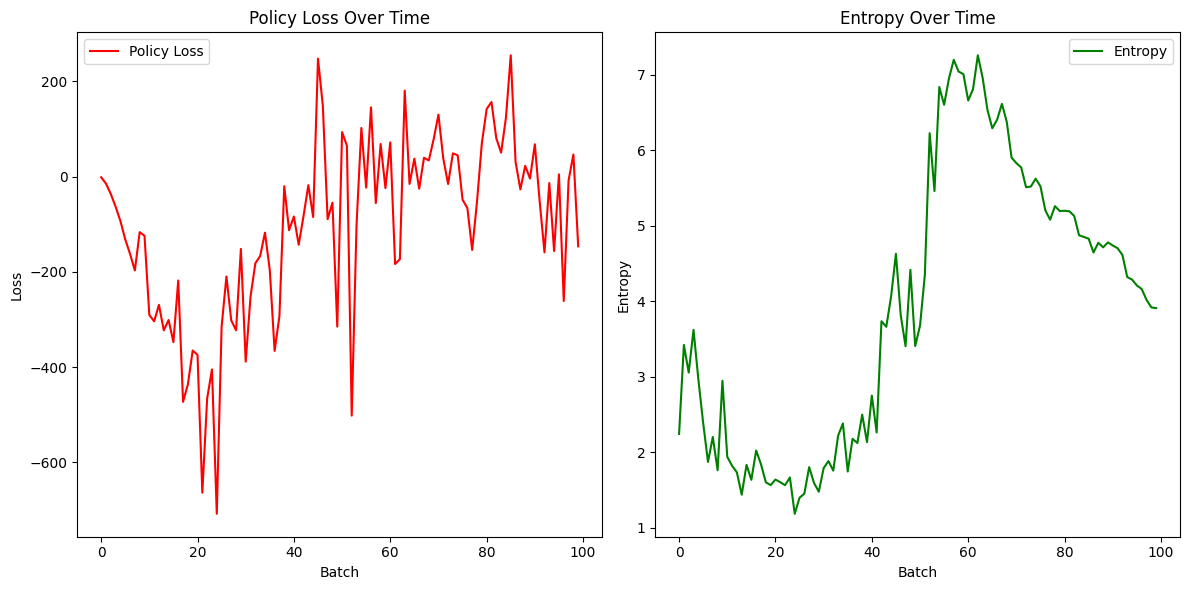

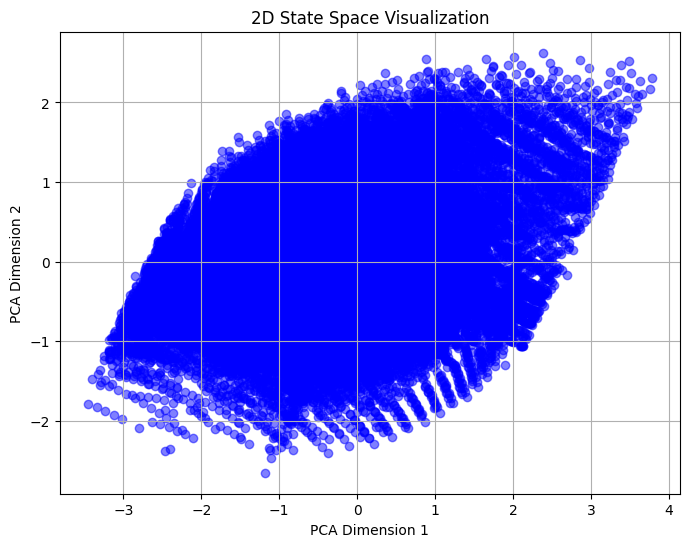

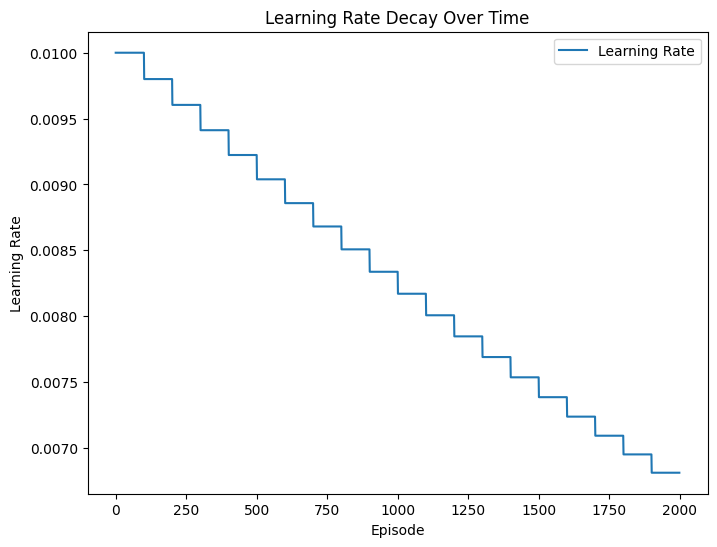

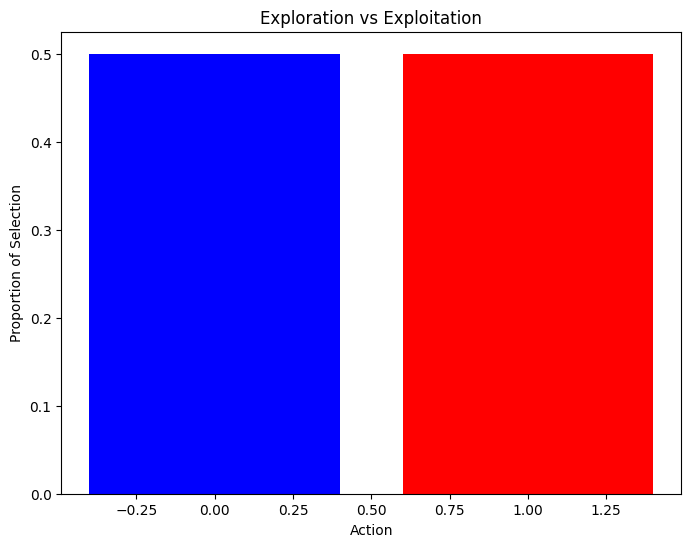

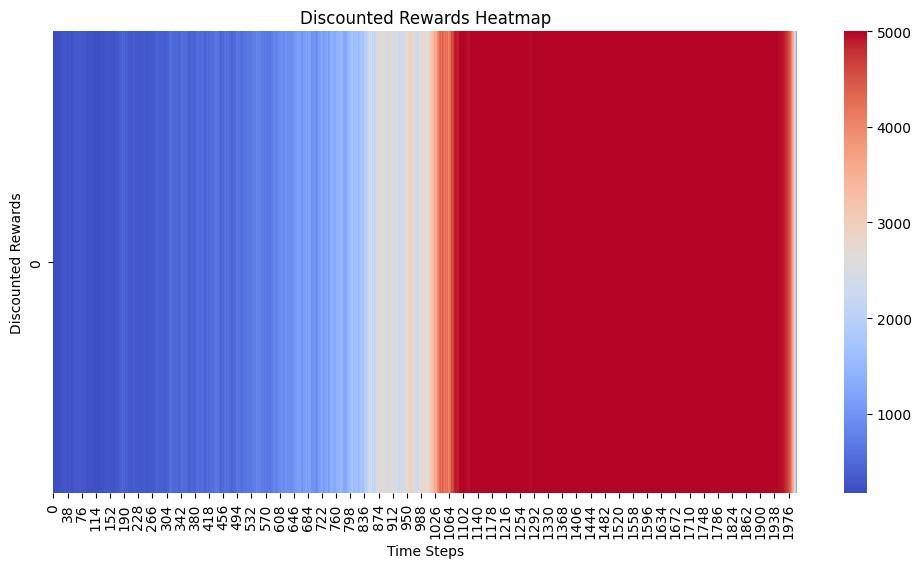

In [31]:
plotter.plot_reward_training_loss_curve()
plotter.plot_rewards_and_episode_lengths(episode_rewards, smoothed_rewards, episode_lengths)
plotter.plot_discounted_rewards(episode_rewards, gamma=GAMMA)
plotter.plot_action_distribution(action_distribution, env)
plotter.plot_policy_heatmap(policy_net, env)
plotter.plot_loss_and_entropy(losses=losses, entropies=entropies)
plotter.plot_state_space(all_states)
plotter.plot_learning_rate_decay(learning_rates=learning_rates)
plotter.plot_exploration_vs_exploitation(action_distribution)
plotter.plot_discounted_rewards_heatmap(episode_rewards, gamma=GAMMA)

## Train the agent for defined parameters

In [32]:
LEARNING_RATE = 0.01
GAMMA = 0.97
BATCH_SIZE = 32
ENTROPY_BETA_START = 0.1
ENTROPY_BETA_END = 0.01
ENTROPY_DECAY = 0.997
LR_DECAY_RATE = 0.99
LR_DECAY_INTERVAL = 1000
MAX_EPISODES = 2000


env = gym.make("CartPole-v1")
policy_net = ReinforcementLearningPolicyNetwork(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
episode_rewards3, smoothed_rewards3, episode_lengths3, losses3, action_distribution3, entropies3, learning_rates3, all_states3 = train_agent_with_policy_gradient(
    env,
    policy_net,
    optimizer,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    entropy_decay=ENTROPY_DECAY,
    entropy_beta_start=ENTROPY_BETA_START,
    entropy_beta_end=ENTROPY_BETA_END,
    lr_decay_rate=LR_DECAY_RATE,
    lr_decay_interval=LR_DECAY_INTERVAL,
    episodes=MAX_EPISODES,
    )

Episode: 0, Total Reward: 15.0, Smoothed Reward: 15.0
Episode: 100, Total Reward: 27.0, Smoothed Reward: 21.94
Episode: 200, Total Reward: 35.0, Smoothed Reward: 30.76
Episode: 300, Total Reward: 12.0, Smoothed Reward: 37.36
Episode: 400, Total Reward: 101.0, Smoothed Reward: 53.56
Episode: 500, Total Reward: 28.0, Smoothed Reward: 46.74
Episode: 600, Total Reward: 50.0, Smoothed Reward: 61.04
Episode: 700, Total Reward: 35.0, Smoothed Reward: 83.5
Episode: 800, Total Reward: 127.0, Smoothed Reward: 95.82
Episode: 900, Total Reward: 289.0, Smoothed Reward: 128.6
Episode: 1000, Total Reward: 292.0, Smoothed Reward: 152.8
Episode: 1100, Total Reward: 490.0, Smoothed Reward: 210.78
Episode: 1200, Total Reward: 296.0, Smoothed Reward: 259.3
Episode: 1300, Total Reward: 216.0, Smoothed Reward: 266.46
Episode: 1400, Total Reward: 287.0, Smoothed Reward: 318.34
Episode: 1500, Total Reward: 213.0, Smoothed Reward: 368.88
Episode: 1600, Total Reward: 500.0, Smoothed Reward: 481.08
Episode: 1700

## Plot and analyse training for the given parameters

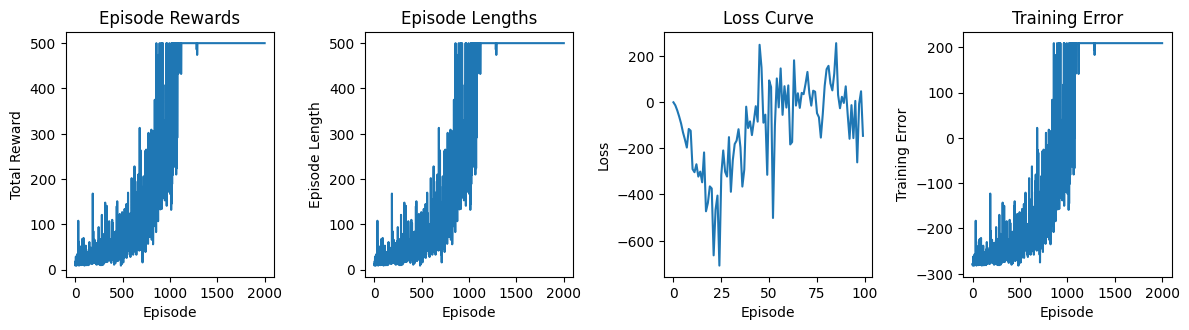

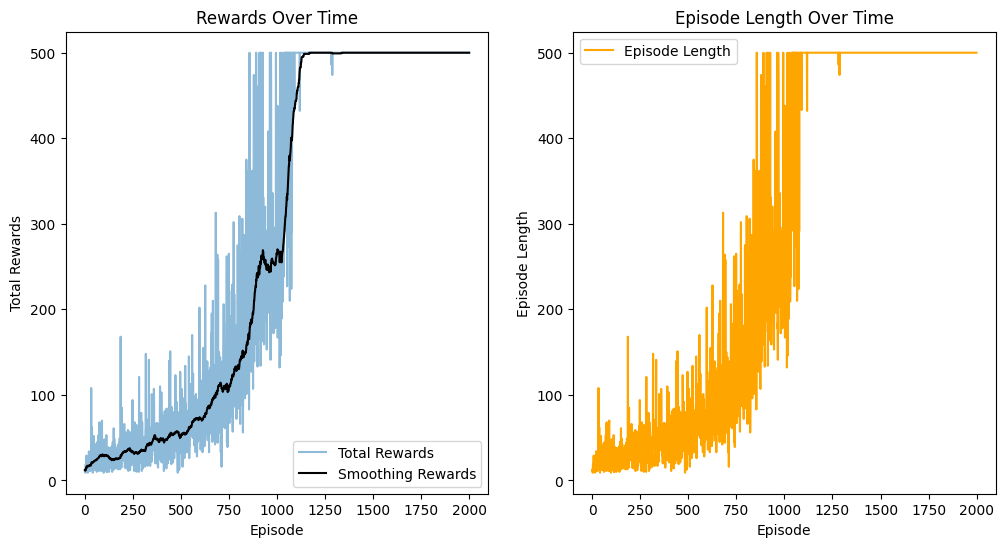

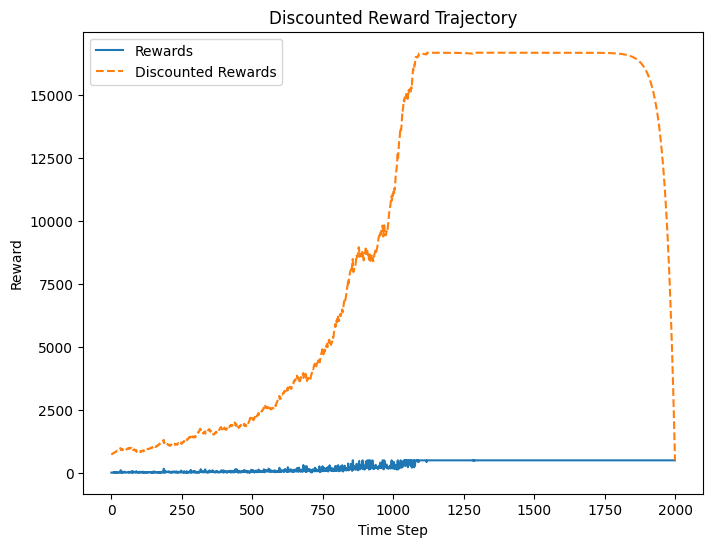

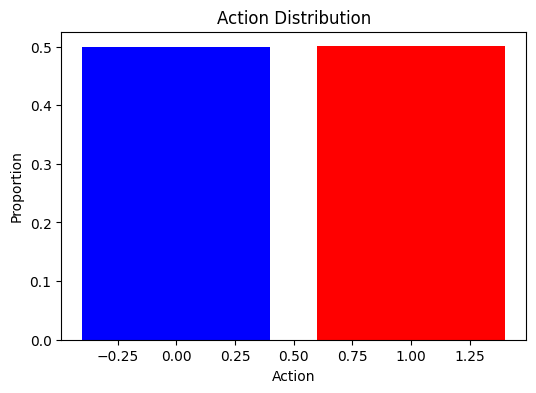

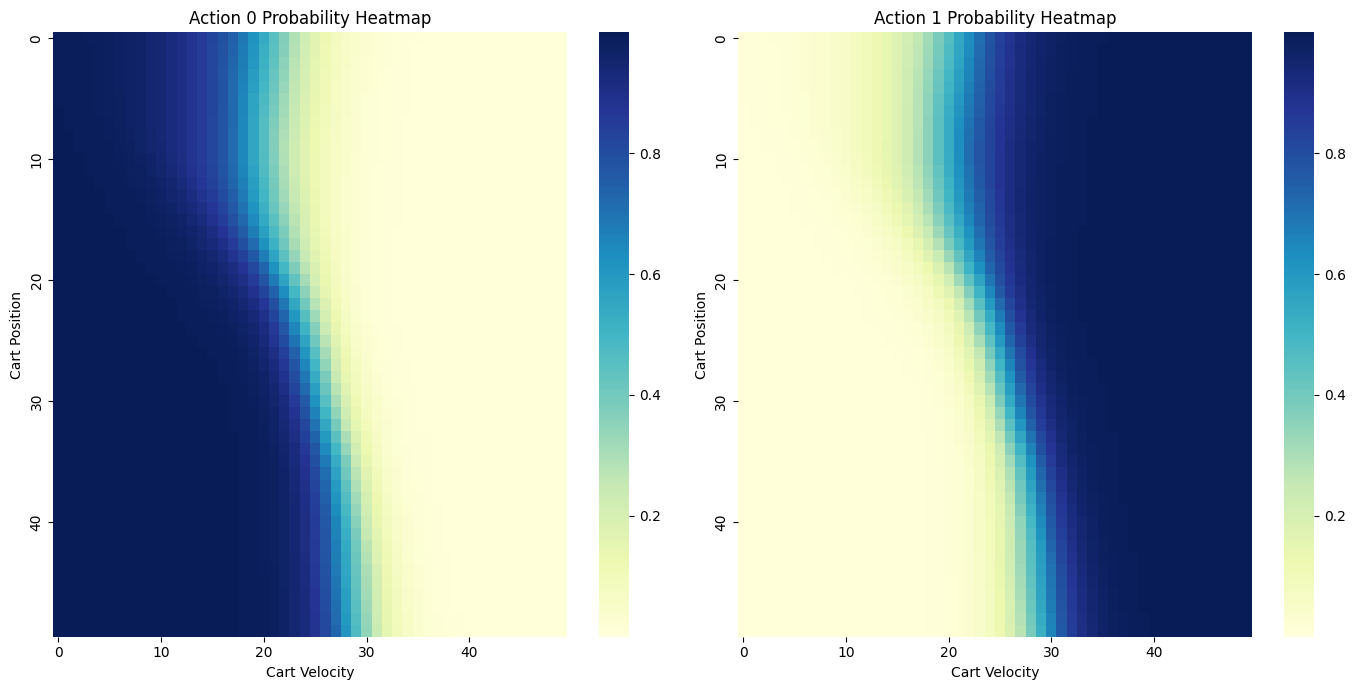

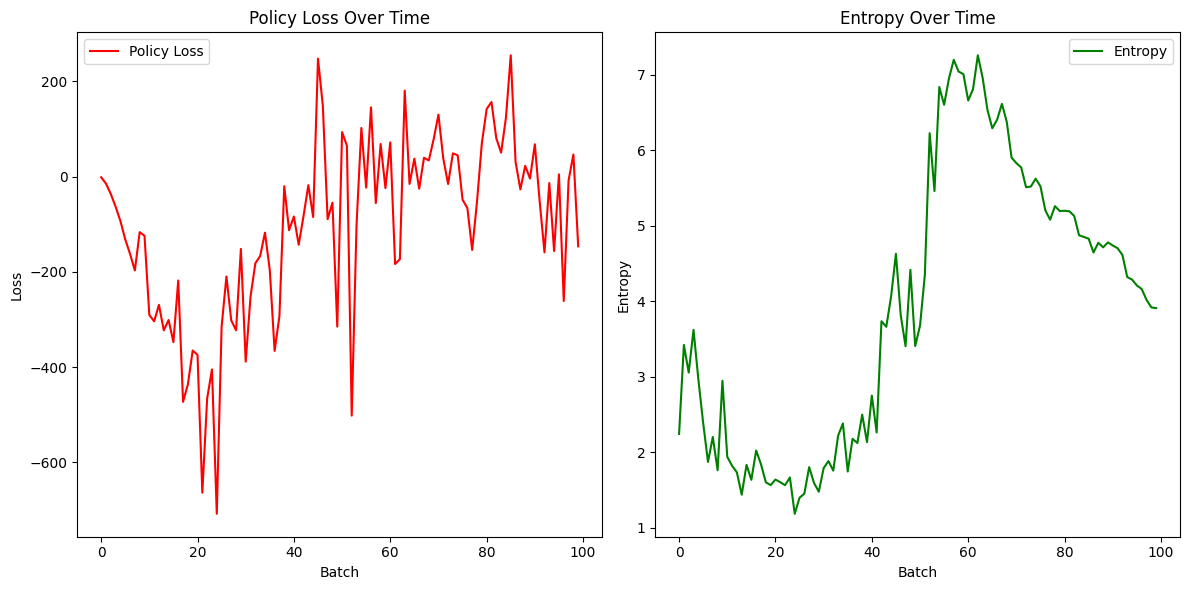

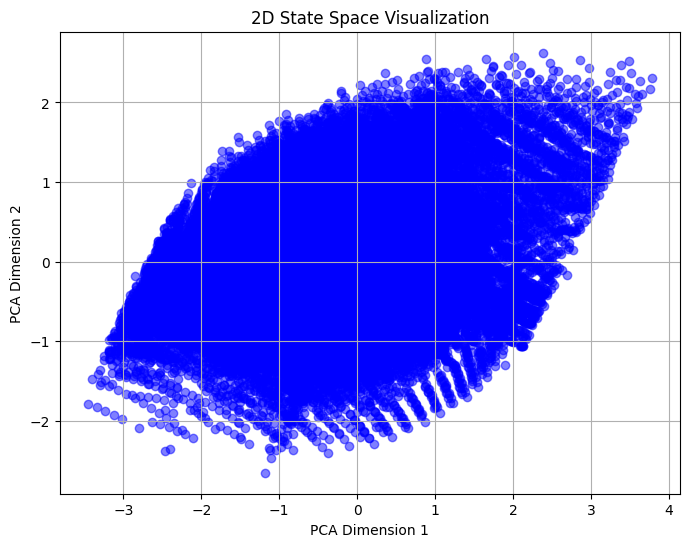

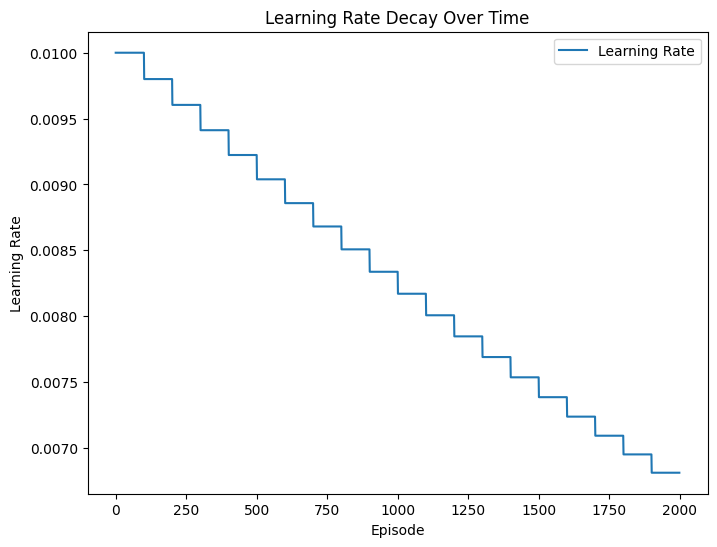

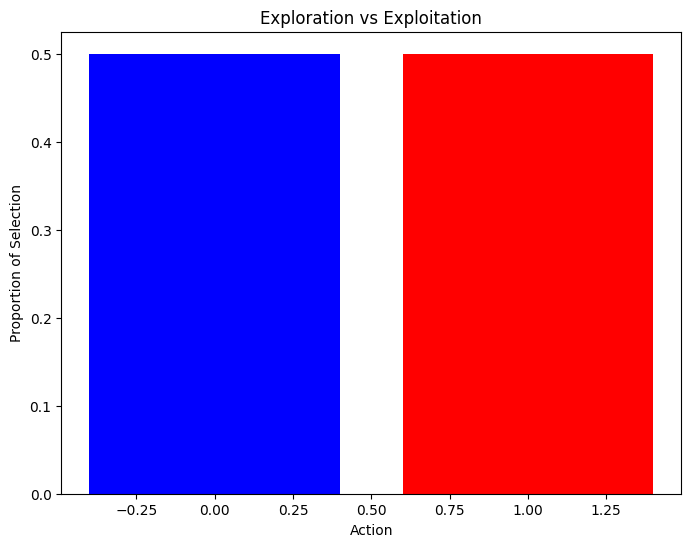

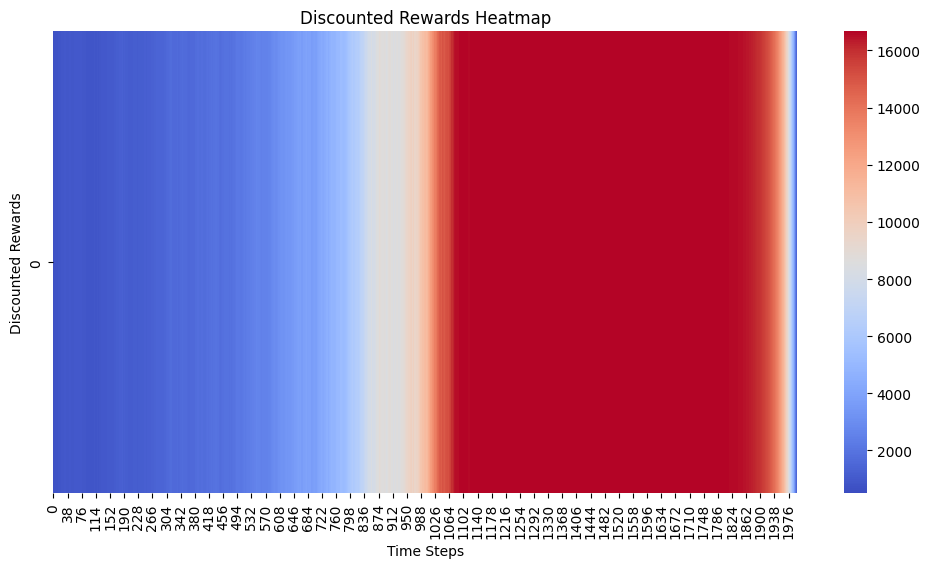

In [33]:
plotter.plot_reward_training_loss_curve()
plotter.plot_rewards_and_episode_lengths(episode_rewards, smoothed_rewards, episode_lengths)
plotter.plot_discounted_rewards(episode_rewards, gamma=GAMMA)
plotter.plot_action_distribution(action_distribution, env)
plotter.plot_policy_heatmap(policy_net, env)
plotter.plot_loss_and_entropy(losses=losses, entropies=entropies)
plotter.plot_state_space(all_states)
plotter.plot_learning_rate_decay(learning_rates=learning_rates)
plotter.plot_exploration_vs_exploitation(action_distribution)
plotter.plot_discounted_rewards_heatmap(episode_rewards, gamma=GAMMA)